# Paramétrage de l'environnement de travail et import des packages

In [4]:
import sys
from pathlib import Path

In [5]:
ROOT = Path.cwd().parents[0]

MODEL_DATA = ROOT / "04_model"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd
import numpy as np
import shap
from fonctions_perso.machine_learning import waterfall_plot
import joblib
from sklearn import set_config

# Interpretation - SHAP

**Import de x_test | y_test et du modèle non calibré**

In [7]:
# x_test
x_test = joblib.load(PROCESSED_DATA / "x_test_for_shap.joblib")

# y_test
y_test = joblib.load(PROCESSED_DATA / "y_test_for_shap.joblib")

# modèle
modele = joblib.load(MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")

In [8]:
full_test = pd.concat([x_test,y_test], axis = 1)

**Initialisation**

In [ ]:
set_config(transform_output="pandas")

# Appliquer toutes les étapes sans le modèle
x_test_proc = modele[:-1].transform(x_test)

# Récuperer le modèle "nu"
xgb = modele.named_steps["model"]

# Initialisation de l'explainer
explainer = shap.TreeExplainer(xgb, x_test_proc)

shap_values = explainer(x_test_proc)

100%|===================| 281240/281521 [10:54<00:00]        

**Sauvegarde des objets**

In [10]:
joblib.dump(shap_values, MODEL_DATA / "shap_values_model.joblib")

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\04_model\\shap_values_model.joblib']

In [ ]:
# shap_values = joblib.load(MODEL_DATA / "shap_values_model.joblib")

**Feature Importance**

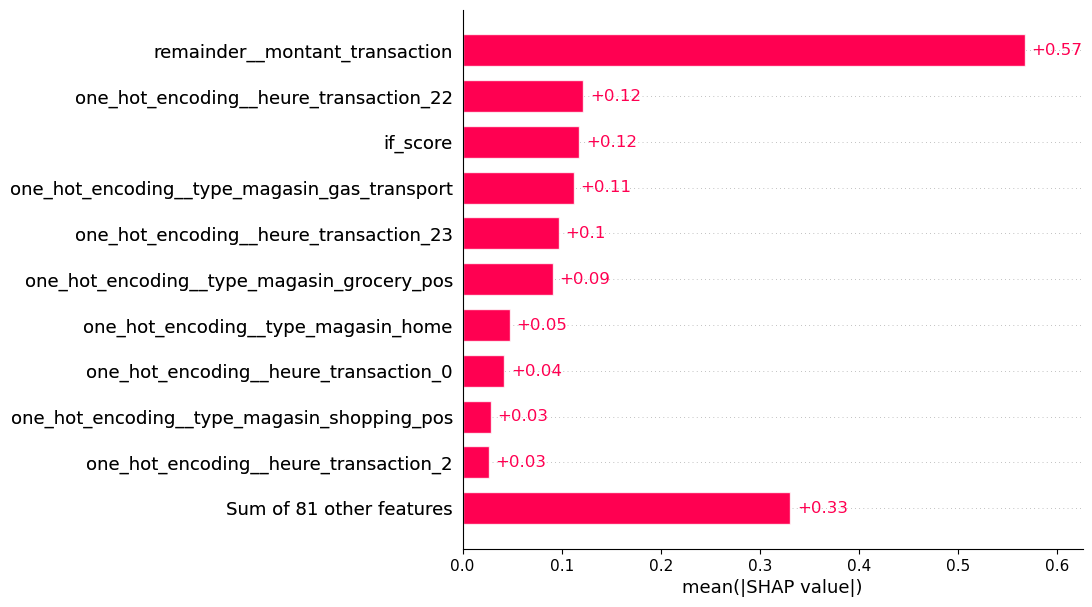

In [11]:
shap.plots.bar(shap_values, max_display=11)

**Beeswarm Plot**

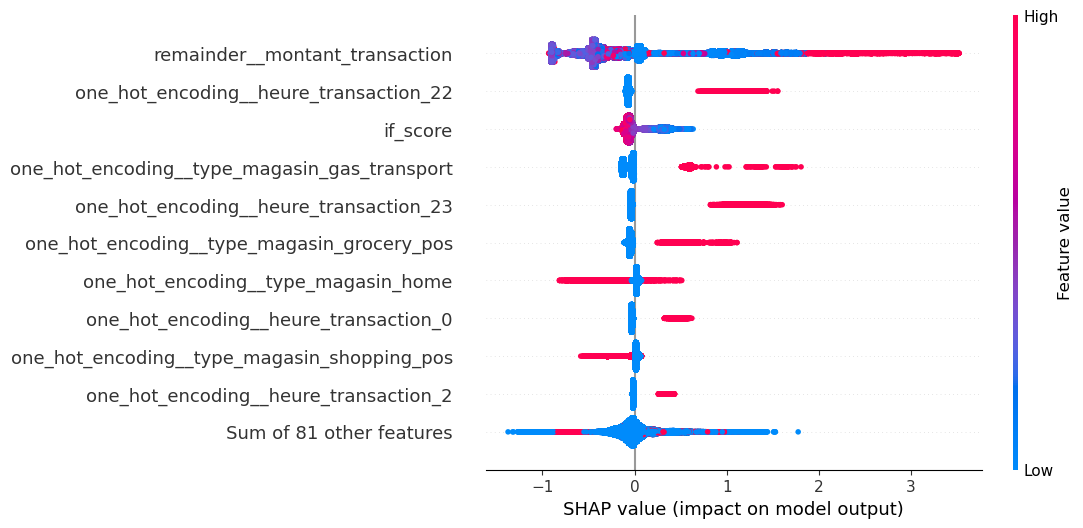

In [12]:
shap.plots.beeswarm(shap_values, max_display=11)

**Waterfall Plot**

In [13]:
full_test[full_test["target"]==1].sample(15)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
314113,misc_net,773.33,VA,43102,22,120.223955,70,1
387625,misc_net,875.38,PA,606,23,53.684032,23,1
405115,shopping_net,957.90,MI,2223,23,75.779987,34,1
328127,gas_transport,12.40,IA,1071,6,60.273231,22,1
325967,grocery_pos,283.58,IL,3119,3,106.499263,78,1
306128,misc_net,708.51,AZ,1312922,23,84.552385,21,1
436725,grocery_pos,319.21,OH,1443,3,79.437460,58,1
390207,grocery_pos,298.21,ID,4161,11,87.753309,63,1
282836,grocery_pos,308.81,MI,96942,3,54.156523,55,1
279807,grocery_pos,357.63,NY,4015,0,49.964298,49,1


In [14]:
full_test[full_test["target"]==0].sample(15)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
500703,misc_net,37.64,NY,2258,4,108.846302,83,0
290635,gas_transport,63.65,MT,1446,7,69.626853,42,0
281685,home,71.57,WV,4575,18,90.580408,29,0
442949,grocery_pos,23.62,other,601723,6,81.143781,29,0
277340,entertainment,54.03,NC,186140,19,54.826162,37,0
502761,health_fitness,45.71,TX,5875,15,120.489783,28,0
418893,travel,8.21,TN,158701,12,35.157868,42,0
418099,entertainment,3.52,IL,6713,9,47.936911,75,0
474634,gas_transport,72.74,TN,25459,5,83.986772,51,0
544542,misc_pos,250.43,IA,568,6,23.879164,51,0


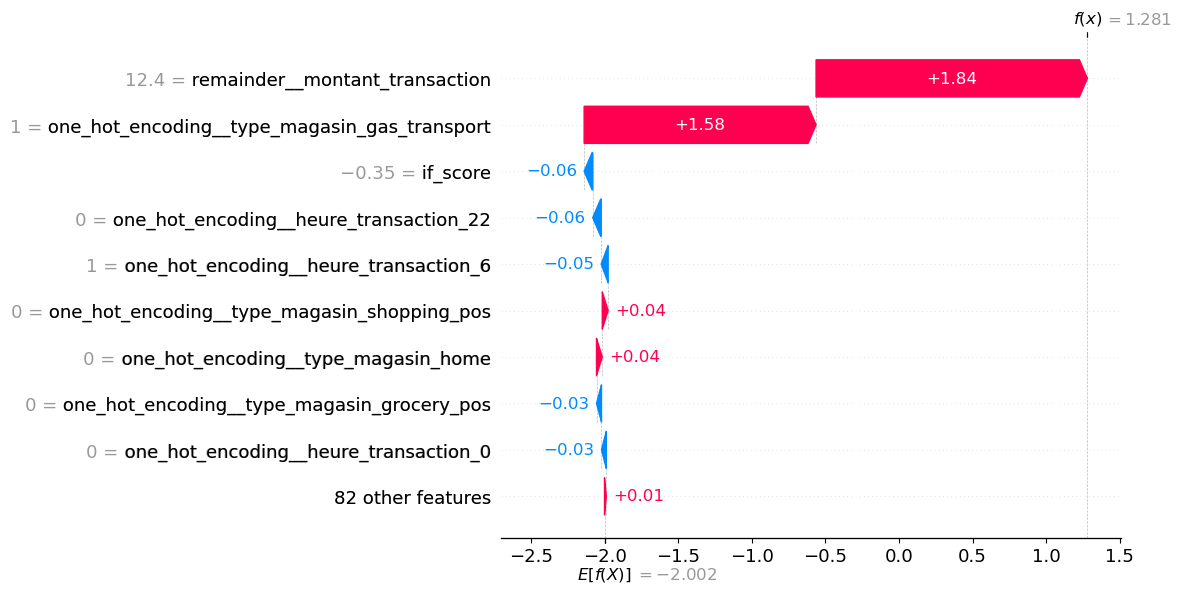

In [15]:
waterfall_plot(
    shap_values,
    x_test_proc,
    328127,
    max_display=10
)